# Regression — Metro Interstate Traffic Volume

## Objective

The objective of this regression task is to predict hourly traffic volume using
weather conditions, holiday information, and time-related features.

The target variable is `traffic_volume`.

The analysis includes exploratory data analysis, data cleaning,
feature engineering, preprocessing, implementation of 10 regression
algorithms, comparative evaluation, hyperparameter tuning, and
result visualization.

In [62]:
# Import pandas for working with tabular data
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for visualizations
import matplotlib.pyplot as plt

# Import seaborn for statistical visualizations
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Set a standard figure size for plots
plt.rcParams["figure.figsize"] = (10, 6)

# Confirm that the libraries were imported
print("Libraries imported successfully.")

Libraries imported successfully.


# Section A — Exploratory Data Analysis

This section explores the Metro Interstate Traffic Volume dataset to understand its structure, data quality, target variable, and relationships between traffic volume and the available features.

The analysis includes dataset inspection, missing-value analysis, duplicate detection, descriptive statistics, distribution analysis, and visualization of important relationships.


In [63]:
# Load the Metro Interstate Traffic Volume dataset
df = pd.read_csv("../data/Metro_Interstate_Traffic_Volume.csv")

# Display the first five rows of the dataset
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [64]:
# Display the number of rows and columns in the dataset
print("Dataset shape:", df.shape)

# Display the number of rows
print("Number of rows:", df.shape[0])

# Display the number of columns
print("Number of columns:", df.shape[1])

Dataset shape: (48204, 9)
Number of rows: 48204
Number of columns: 9


In [65]:
# Display detailed information about the dataset
# This shows column names, data types, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 5.0 MB


In [66]:
# Count the number of missing values in each column
missing_values = df.isnull().sum()

# Display the missing-value counts
print("Missing values in each column:")
display(missing_values)

Missing values in each column:


holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

In [67]:
# Count the number of duplicate rows in the dataset
duplicate_count = df.duplicated().sum()

# Display the duplicate count
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 17


In [68]:
# Define the target variable for our regression problem
target_column = "traffic_volume"

# Display basic statistical information about the target
print("Target variable:", target_column)
print()

print("Target variable statistics:")
display(df[target_column].describe())

Target variable: traffic_volume

Target variable statistics:


count    48204.000000
mean      3259.818355
std       1986.860670
min          0.000000
25%       1193.000000
50%       3380.000000
75%       4933.000000
max       7280.000000
Name: traffic_volume, dtype: float64

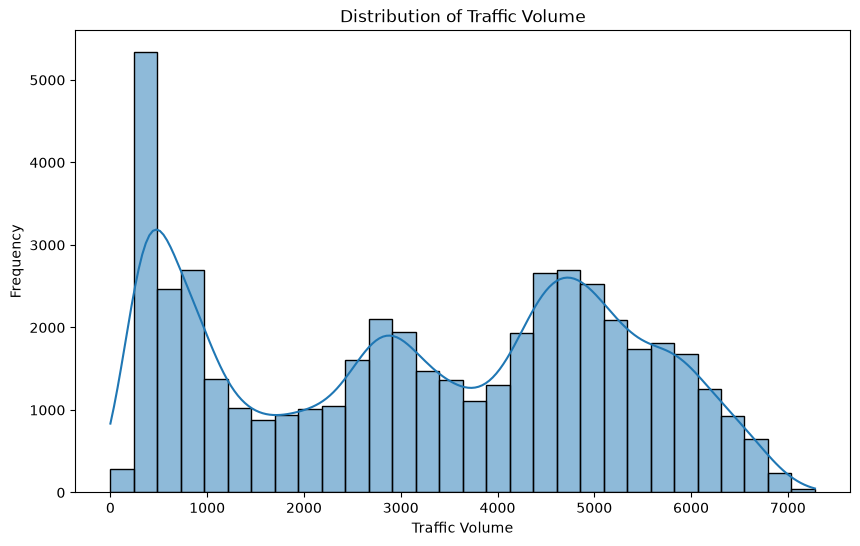

In [69]:
# Create a histogram to show the distribution of traffic volume
plt.figure(figsize=(10, 6))

# Plot the distribution of the target variable
sns.histplot(
    data=df,
    x="traffic_volume",
    bins=30,
    kde=True
)

# Add a title to the plot
plt.title("Distribution of Traffic Volume")

# Label the x-axis
plt.xlabel("Traffic Volume")

# Label the y-axis
plt.ylabel("Frequency")

# Display the plot
plt.show()

### Observation

The distribution of traffic volume is not symmetric and shows multiple peaks at different traffic-volume ranges. A large concentration of observations occurs at lower traffic volumes, while another substantial concentration appears around 4,500–5,500 vehicles. The target values range from 0 to approximately 7,280, indicating substantial variation in traffic volume. The multiple peaks suggest that traffic volume may be influenced by factors such as time of day, weather conditions, and holidays.

In [70]:
# Select all numerical columns from the dataset
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

# Display the numerical column names
print("Numerical columns:")
print(list(numerical_columns))

Numerical columns:
['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume']


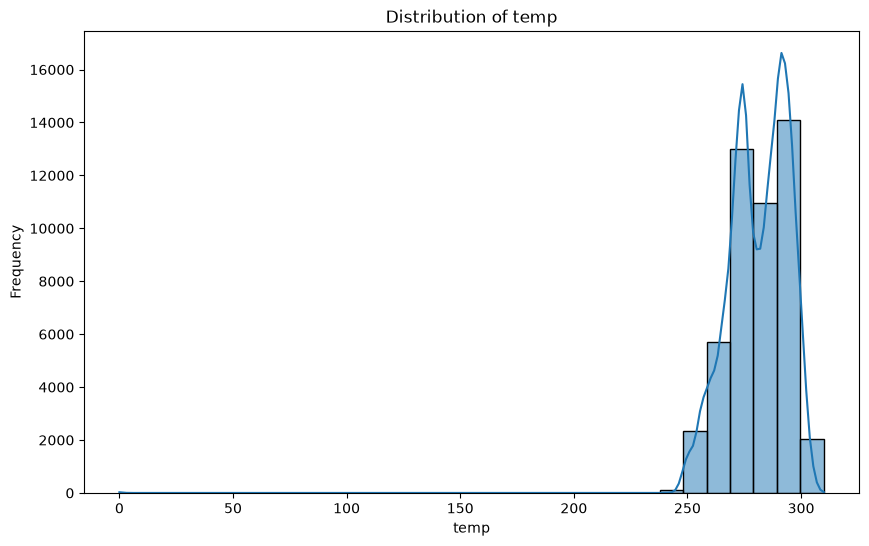

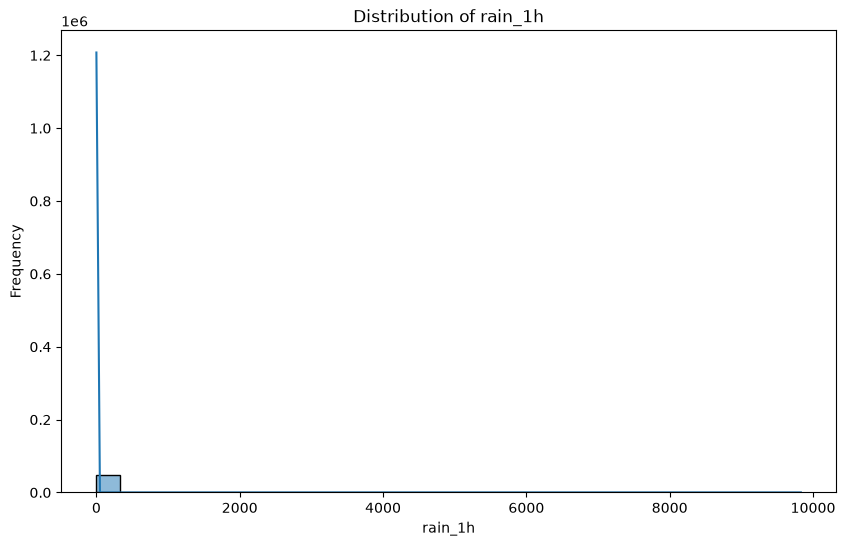

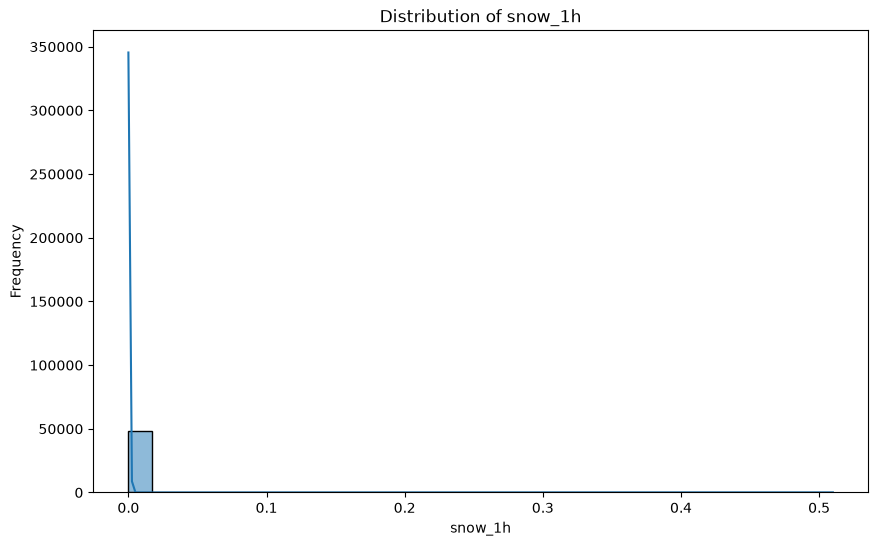

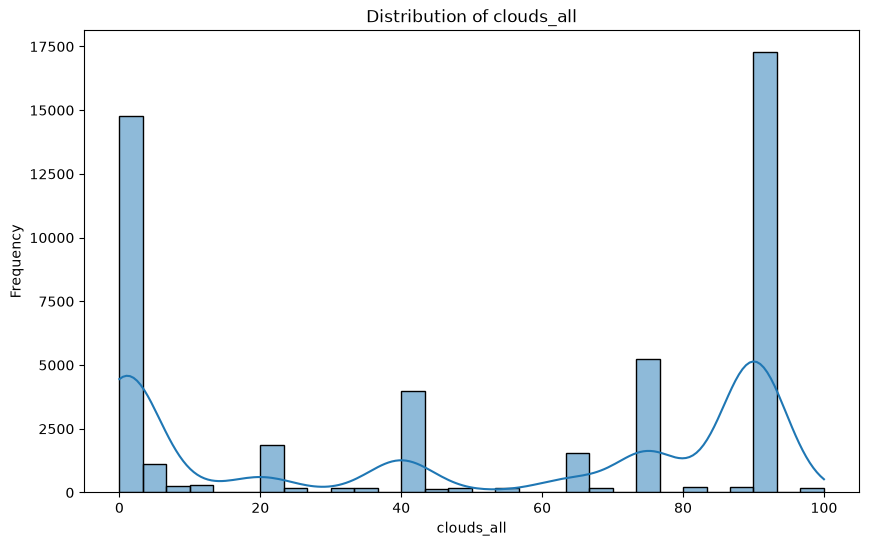

In [71]:
# Create a separate distribution plot for each numerical input feature
for column in numerical_columns:

    # Skip the target variable because it was already plotted separately
    if column == target_column:
        continue

    # Create a new figure for the current feature
    plt.figure(figsize=(10, 6))

    # Plot the distribution using a histogram and KDE curve
    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True
    )

    # Add a title using the feature name
    plt.title(f"Distribution of {column}")

    # Label the x-axis
    plt.xlabel(column)

    # Label the y-axis
    plt.ylabel("Frequency")

    # Display the plot
    plt.show()

### Observations

- **Temperature (`temp`)**: The temperature values are mainly concentrated between approximately 250 and 310, with a small number of unusually low values that may require further investigation during data cleaning.

- **Rain (`rain_1h`)**: The distribution is highly right-skewed, with most observations close to zero and a small number of observations having much larger rainfall values.

- **Snow (`snow_1h`)**: Most observations have values close to zero, indicating that snowfall is uncommon in the dataset. A small number of non-zero values are present.

- **Cloud coverage (`clouds_all`)**: Cloud coverage is distributed across several levels, with particularly high frequencies around 0 and 90. This indicates that clear and highly cloudy conditions occur frequently in the dataset.

In [72]:
# Identify the categorical columns in the dataset
categorical_columns = df.select_dtypes(include=["object"]).columns

# Display the categorical column names
print("Categorical columns:")
print(list(categorical_columns))

Categorical columns:
['holiday', 'weather_main', 'weather_description', 'date_time']


C:\Users\SAPTHAGIRI REDDY\AppData\Local\Temp\ipykernel_35316\590994719.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


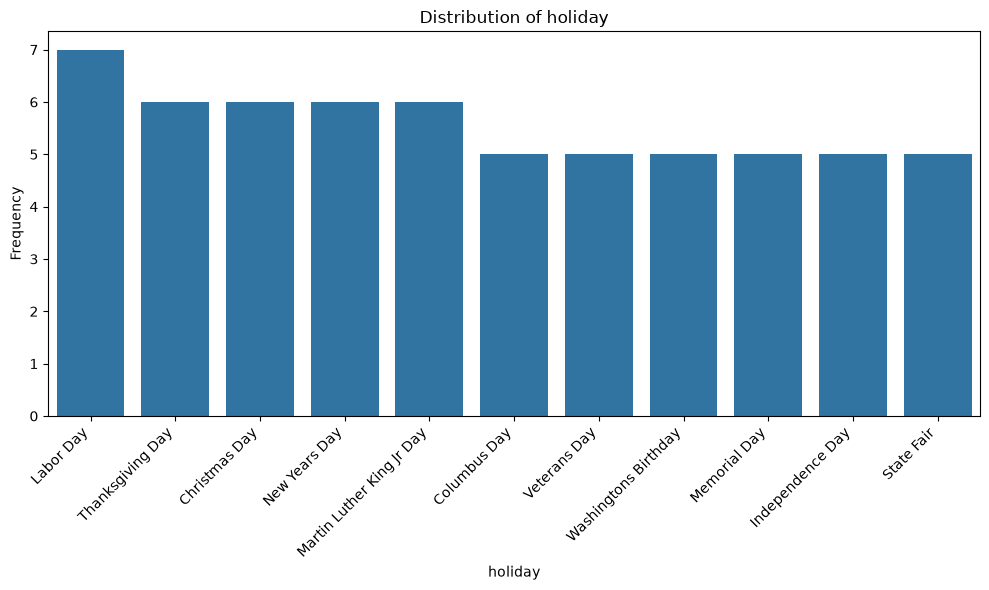

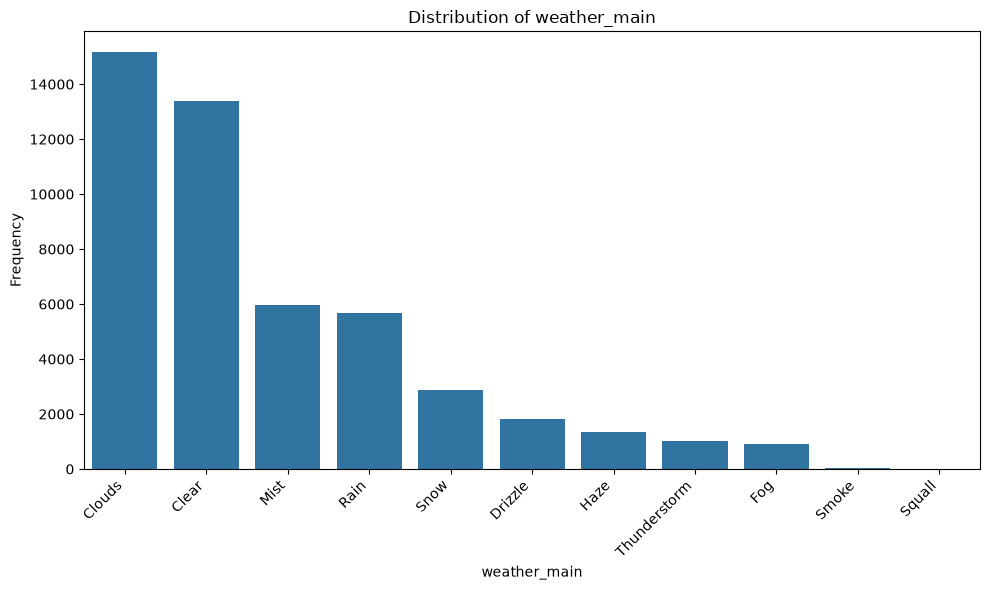

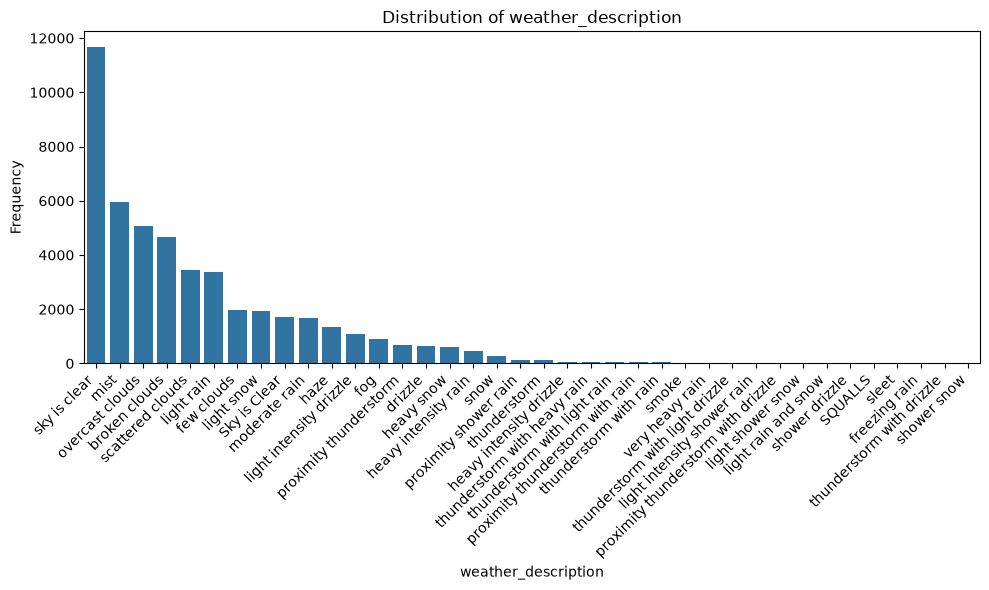

In [73]:
# Select categorical features, excluding the date-time column
categorical_features = [
    column for column in categorical_columns
    if column != "date_time"
]

# Create a separate count plot for each categorical feature
for column in categorical_features:

    # Create a new figure for the current feature
    plt.figure(figsize=(10, 6))

    # Count the number of observations in each category
    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )

    # Add a title
    plt.title(f"Distribution of {column}")

    # Label the x-axis
    plt.xlabel(column)

    # Label the y-axis
    plt.ylabel("Frequency")

    # Rotate labels to make them easier to read
    plt.xticks(rotation=45, ha="right")

    # Adjust spacing so labels are not cut off
    plt.tight_layout()

    # Display the plot
    plt.show()

### Observations

- **Holiday:** Only a small number of observations correspond to named holidays, while most records have no holiday information. The individual holiday categories have relatively small and similar frequencies.

- **Weather Main:** The most frequently recorded weather conditions are `Clouds` and `Clear`, followed by `Mist` and `Rain`. Some conditions, such as `Smoke` and `Squall`, occur very rarely.

- **Weather Description:** `sky is clear` is the most frequent weather description, followed by `mist` and several cloud-related conditions. The distribution contains many less frequent weather descriptions, showing that some detailed weather conditions are relatively rare.

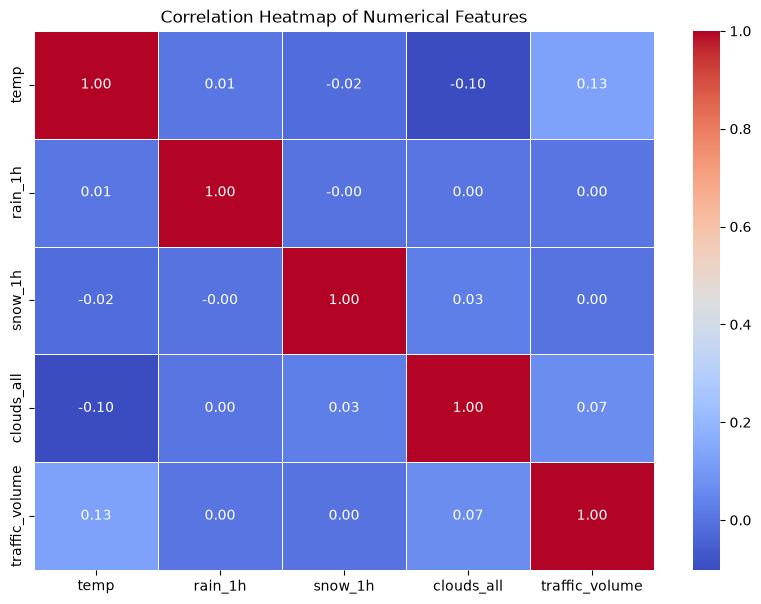

In [74]:
# Select only numerical columns for correlation analysis
correlation_data = df[numerical_columns]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Create a heatmap of the correlations
plt.figure(figsize=(10, 7))

# Display the correlation matrix using a heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

# Add a title
plt.title("Correlation Heatmap of Numerical Features")

# Display the plot
plt.show()

### Observation

The correlation heatmap shows that the numerical features have generally weak linear relationships with the target variable, `traffic_volume`. Temperature (`temp`) has the strongest positive correlation with traffic volume at 0.13, followed by cloud coverage (`clouds_all`) at 0.07. Rainfall (`rain_1h`) and snowfall (`snow_1h`) have correlations close to zero with traffic volume. The numerical predictors also show very weak correlations with each other, suggesting limited linear multicollinearity among these variables.

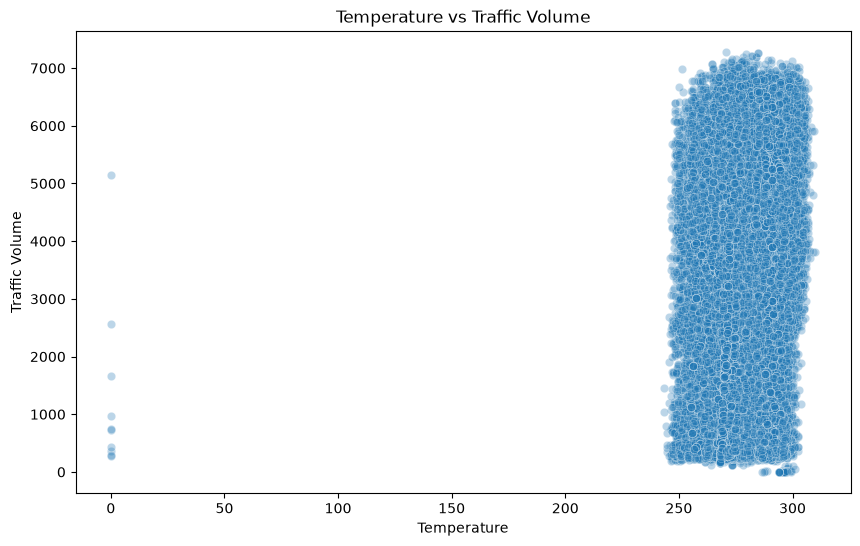

In [75]:
# Create a scatter plot of temperature against traffic volume
plt.figure(figsize=(10, 6))

# Plot temperature on the x-axis and traffic volume on the y-axis
sns.scatterplot(
    data=df,
    x="temp",
    y="traffic_volume",
    alpha=0.3
)

# Add a title
plt.title("Temperature vs Traffic Volume")

# Label the x-axis
plt.xlabel("Temperature")

# Label the y-axis
plt.ylabel("Traffic Volume")

# Display the plot
plt.show()

### Observation

The scatter plot shows a wide spread of traffic volume across most temperature values, with no clear strong linear relationship between temperature and traffic volume. This is consistent with the weak positive correlation of 0.13 observed in the correlation heatmap. A few observations have unusually low temperature values near 0 compared with the main range of the data, which will be investigated during the data-cleaning stage.

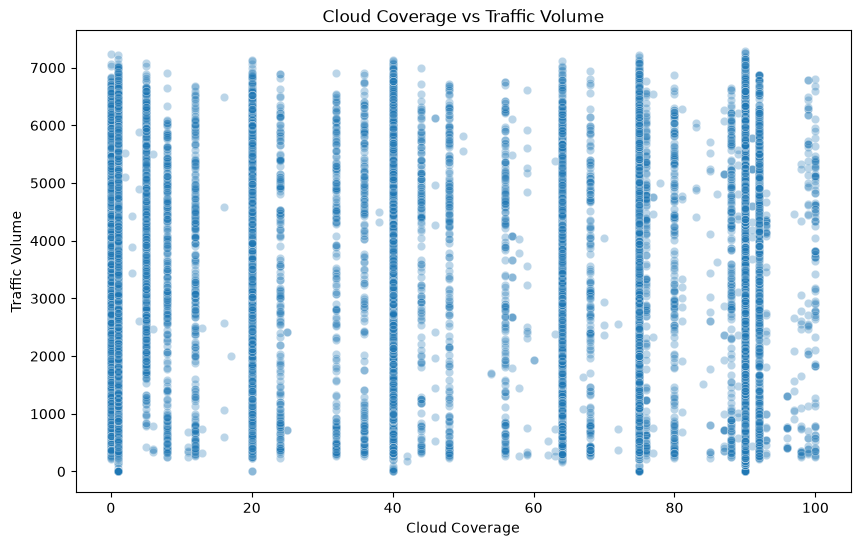

In [76]:
# Create a scatter plot of cloud coverage against traffic volume
plt.figure(figsize=(10, 6))

# Plot cloud coverage on the x-axis and traffic volume on the y-axis
sns.scatterplot(
    data=df,
    x="clouds_all",
    y="traffic_volume",
    alpha=0.3
)

# Add a title
plt.title("Cloud Coverage vs Traffic Volume")

# Label the x-axis
plt.xlabel("Cloud Coverage")

# Label the y-axis
plt.ylabel("Traffic Volume")

# Display the plot
plt.show()

### Observation

The scatter plot shows that traffic volume varies widely across different levels of cloud coverage, with no clear strong linear relationship between the two variables. This is consistent with the weak correlation of 0.07 observed in the correlation heatmap. Therefore, cloud coverage alone does not appear to be a strong linear predictor of traffic volume.

# Section B — Preprocessing & Feature Engineering

This section prepares the Metro Interstate Traffic Volume dataset for regression modelling.

The preprocessing steps include:

1. **Data Cleaning**
   - Handle missing values using an appropriate and justified strategy.
   - Check and treat duplicate records.
   - Investigate unusual values and potential outliers without removing valid observations unnecessarily.

2. **Encoding, Scaling & Data Splitting**
   - Separate the target variable (`traffic_volume`) from the input features.
   - Convert the `date_time` column into useful time-based features.
   - Encode categorical variables appropriately.
   - Apply feature scaling where required by the regression algorithms.
   - Split the data into training and testing sets while ensuring that preprocessing is fitted using the training data only.

3. **Feature Engineering**
   - Create at least one meaningful engineered feature from the available data.
   - Provide a justification explaining how the engineered feature may help predict traffic volume.

The preprocessing pipeline will be kept consistent so that all 10 regression algorithms are trained and evaluated using the same prepared data and test set.

In [77]:
# Display the unique values in the holiday column
print("Unique values in holiday:")
print(df["holiday"].unique())

# Display the frequency of each holiday value
print("\nFrequency of each holiday value:")
display(df["holiday"].value_counts(dropna=False))

Unique values in holiday:
<ArrowStringArray>
[                        nan,              'Columbus Day',
              'Veterans Day',          'Thanksgiving Day',
             'Christmas Day',             'New Years Day',
      'Washingtons Birthday',              'Memorial Day',
          'Independence Day',                'State Fair',
                 'Labor Day', 'Martin Luther King Jr Day']
Length: 12, dtype: str

Frequency of each holiday value:


holiday
NaN                          48143
Labor Day                        7
Thanksgiving Day                 6
Christmas Day                    6
New Years Day                    6
Martin Luther King Jr Day        6
Columbus Day                     5
Veterans Day                     5
Washingtons Birthday             5
Memorial Day                     5
Independence Day                 5
State Fair                       5
Name: count, dtype: int64

In [78]:
# Store the number of rows before removing duplicates
rows_before = len(df)

# Remove duplicate rows
df = df.drop_duplicates().copy()

# Store the number of rows after removing duplicates
rows_after = len(df)

# Calculate how many rows were removed
duplicates_removed = rows_before - rows_after

# Display the cleaning result
print("Rows before removing duplicates:", rows_before)
print("Rows after removing duplicates:", rows_after)
print("Duplicate rows removed:", duplicates_removed)

Rows before removing duplicates: 48204
Rows after removing duplicates: 48187
Duplicate rows removed: 17


In [79]:
# Select the numerical input features
numerical_features = [
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all"
]

# Display minimum and maximum values for each numerical feature
range_check = df[numerical_features].agg(["min", "max"]).T

# Display the results
print("Minimum and maximum values:")
display(range_check)

Minimum and maximum values:


,min,max
temp,0.0,310.07
rain_1h,0.0,9831.30
snow_1h,0.0,0.51
clouds_all,0.0,100.00


In [80]:
# Check for potential outliers using the Interquartile Range (IQR) method

# Loop through each numerical input feature
for column in numerical_features:

    # Calculate the first quartile (25th percentile)
    Q1 = df[column].quantile(0.25)

    # Calculate the third quartile (75th percentile)
    Q3 = df[column].quantile(0.75)

    # Calculate the Interquartile Range
    IQR = Q3 - Q1

    # Calculate the lower outlier boundary
    lower_bound = Q1 - 1.5 * IQR

    # Calculate the upper outlier boundary
    upper_bound = Q3 + 1.5 * IQR

    # Count observations below the lower boundary
    lower_outliers = (df[column] < lower_bound).sum()

    # Count observations above the upper boundary
    upper_outliers = (df[column] > upper_bound).sum()

    # Display the results
    print(f"\nFeature: {column}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Lower outliers: {lower_outliers}")
    print(f"Upper outliers: {upper_outliers}")


Feature: temp
Q1: 272.16
Q3: 291.81
IQR: 19.65
Lower bound: 242.69
Upper bound: 321.27
Lower outliers: 10
Upper outliers: 0

Feature: rain_1h
Q1: 0.00
Q3: 0.00
IQR: 0.00
Lower bound: 0.00
Upper bound: 0.00
Lower outliers: 0
Upper outliers: 3467

Feature: snow_1h
Q1: 0.00
Q3: 0.00
IQR: 0.00
Lower bound: 0.00
Upper bound: 0.00
Lower outliers: 0
Upper outliers: 63

Feature: clouds_all
Q1: 1.00
Q3: 90.00
IQR: 89.00
Lower bound: -132.50
Upper bound: 223.50
Lower outliers: 0
Upper outliers: 0


In [81]:
# Create a compact summary of potential outliers using the IQR method
outlier_summary = []

# Check each numerical input feature
for column in numerical_features:

    # Calculate the first quartile
    Q1 = df[column].quantile(0.25)

    # Calculate the third quartile
    Q3 = df[column].quantile(0.75)

    # Calculate the interquartile range
    IQR = Q3 - Q1

    # Calculate the lower boundary
    lower_bound = Q1 - 1.5 * IQR

    # Calculate the upper boundary
    upper_bound = Q3 + 1.5 * IQR

    # Count observations outside the boundaries
    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    # Store the results
    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Potential Outliers": outlier_count
    })

# Convert the results into a DataFrame
outlier_summary = pd.DataFrame(outlier_summary)

# Display the summary
display(outlier_summary)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers
0,temp,272.16,291.806,19.646,242.691,321.275,10
1,rain_1h,0.00,0.000,0.000,0.000,0.000,3467
2,snow_1h,0.00,0.000,0.000,0.000,0.000,63
3,clouds_all,1.00,90.000,89.000,-132.500,223.500,0


In [82]:
# Define the temperature boundaries identified by the IQR method
temp_lower_bound = 242.69
temp_upper_bound = 321.28

# Select the observations outside the normal IQR range
temperature_outliers = df[
    (df["temp"] < temp_lower_bound) |
    (df["temp"] > temp_upper_bound)
]

# Display the unusual temperature observations
print("Potential temperature outliers:")
display(
    temperature_outliers[
        ["temp", "date_time", "traffic_volume"]
    ]
)

Potential temperature outliers:


,temp,date_time,traffic_volume
11898,0.0,2014-01-31 03:00:00,361
11899,0.0,2014-01-31 04:00:00,734
11900,0.0,2014-01-31 05:00:00,2557
11901,0.0,2014-01-31 06:00:00,5150
11946,0.0,2014-02-02 03:00:00,291
11947,0.0,2014-02-02 04:00:00,284
11948,0.0,2014-02-02 05:00:00,434
11949,0.0,2014-02-02 06:00:00,739
11950,0.0,2014-02-02 07:00:00,962
11951,0.0,2014-02-02 08:00:00,1670


In [83]:
# Display the observations with unusually high rainfall values
# The value 100 mm/hour is used as a threshold for investigation
rainfall_extreme = df[df["rain_1h"] > 100]

# Display the number of extreme rainfall observations
print("Number of rainfall observations above 100:", len(rainfall_extreme))

# Display the most extreme rainfall observations
display(
    rainfall_extreme[
        ["rain_1h", "date_time", "traffic_volume"]
    ].sort_values(
        by="rain_1h",
        ascending=False
    ).head(20)
)

Number of rainfall observations above 100: 1


,rain_1h,date_time,traffic_volume
24872,9831.3,2016-07-11 17:00:00,5535


In [84]:
# Display the largest rainfall values in descending order
print("Top 20 rainfall values:")

display(
    df[
        ["rain_1h", "date_time", "traffic_volume"]
    ]
    .sort_values(
        by="rain_1h",
        ascending=False
    )
    .head(20)
)

Top 20 rainfall values:


,rain_1h,date_time,traffic_volume
24872,9831.30,2016-07-11 17:00:00,5535
8247,55.63,2013-08-07 02:00:00,315
7179,44.45,2013-06-24 11:00:00,4802
25779,31.75,2016-08-16 17:00:00,4913
10807,28.70,2013-12-19 23:00:00,1190
10806,28.70,2013-12-19 23:00:00,1190
16505,27.57,2015-07-13 00:00:00,492
16506,27.57,2015-07-13 00:00:00,492
16504,27.57,2015-07-13 00:00:00,492
17439,25.46,2015-08-16 21:00:00,2118


In [85]:
# Treat the identified anomalous temperature values as missing
# Temperature values of 0 are outside the realistic range observed in this dataset
df.loc[df["temp"] == 0, "temp"] = np.nan

# Treat the single extreme rainfall value as missing
# This value is far larger than the next-highest rainfall observation
df.loc[df["rain_1h"] == 9831.30, "rain_1h"] = np.nan

# Count the values that were converted to missing values
temperature_anomalies = df["temp"].isna().sum()
rainfall_anomalies = df["rain_1h"].isna().sum()

# Display the cleaning results
print("Temperature values treated as missing:", temperature_anomalies)
print("Rainfall values treated as missing:", rainfall_anomalies)

Temperature values treated as missing: 10
Rainfall values treated as missing: 1


In [86]:
# Replace missing holiday values with "None"
# This represents observations where no specific holiday is recorded
df["holiday"] = df["holiday"].fillna("None")

# Check whether any missing holiday values remain
remaining_missing_holiday = df["holiday"].isna().sum()

# Display the result
print("Missing holiday values after treatment:", remaining_missing_holiday)

# Display the updated holiday distribution
print("\nUpdated holiday distribution:")
display(df["holiday"].value_counts())

Missing holiday values after treatment: 0

Updated holiday distribution:


holiday
None                         48126
Labor Day                        7
Thanksgiving Day                 6
Christmas Day                    6
New Years Day                    6
Martin Luther King Jr Day        6
Columbus Day                     5
Veterans Day                     5
Washingtons Birthday             5
Memorial Day                     5
Independence Day                 5
State Fair                       5
Name: count, dtype: int64

In [87]:
# Check the number of missing values remaining in every column
remaining_missing = df.isnull().sum()

# Display the missing-value counts
print("Remaining missing values:")
display(remaining_missing)

Remaining missing values:


holiday                 0
temp                   10
rain_1h                 1
snow_1h                 0
clouds_all              0
weather_main            0
weather_description     0
date_time               0
traffic_volume          0
dtype: int64

In [88]:
# Convert the date_time column from text into pandas datetime format
df["date_time"] = pd.to_datetime(df["date_time"])

# Extract the hour of the day
df["hour"] = df["date_time"].dt.hour

# Extract the day of the week
# Monday = 0 and Sunday = 6
df["day_of_week"] = df["date_time"].dt.dayofweek

# Extract the month
df["month"] = df["date_time"].dt.month

# Extract the year
df["year"] = df["date_time"].dt.year

# Create a binary feature indicating whether the day is a weekend
# 1 = Saturday/Sunday, 0 = Monday-Friday
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Display the first five rows of the newly created time features
display(
    df[
        [
            "date_time",
            "hour",
            "day_of_week",
            "month",
            "year",
            "is_weekend"
        ]
    ].head()
)

,date_time,hour,day_of_week,month,year,is_weekend
0,2012-10-02 09:00:00,9,1,10,2012,0
1,2012-10-02 10:00:00,10,1,10,2012,0
2,2012-10-02 11:00:00,11,1,10,2012,0
3,2012-10-02 12:00:00,12,1,10,2012,0
4,2012-10-02 13:00:00,13,1,10,2012,0


In [89]:
# Define a function to categorize each hour into a traffic period
def get_traffic_period(hour):

    # Hours from 5 AM to 11 AM are classified as Morning
    if 5 <= hour <= 11:
        return "Morning"

    # Hours from 12 PM to 4 PM are classified as Afternoon
    elif 12 <= hour <= 16:
        return "Afternoon"

    # Hours from 5 PM to 8 PM are classified as Evening
    elif 17 <= hour <= 20:
        return "Evening"

    # All remaining hours are classified as Night
    else:
        return "Night"


# Apply the function to the hour feature
df["traffic_period"] = df["hour"].apply(get_traffic_period)

# Display the first five rows
display(
    df[
        [
            "date_time",
            "hour",
            "traffic_period",
            "traffic_volume"
        ]
    ].head()
)

,date_time,hour,traffic_period,traffic_volume
0,2012-10-02 09:00:00,9,Morning,5545
1,2012-10-02 10:00:00,10,Morning,4516
2,2012-10-02 11:00:00,11,Morning,4767
3,2012-10-02 12:00:00,12,Afternoon,5026
4,2012-10-02 13:00:00,13,Afternoon,4918


Traffic period distribution:


traffic_period
Night        16234
Morning      14353
Afternoon     9748
Evening       7852
Name: count, dtype: int64

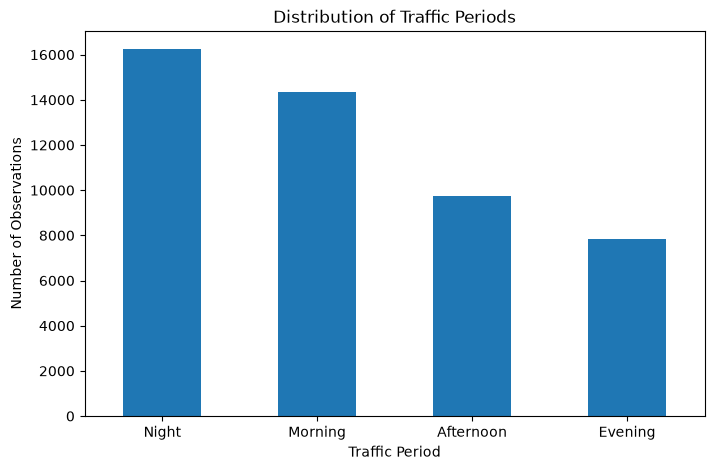

In [90]:
# Count the number of observations in each traffic period
traffic_period_counts = df["traffic_period"].value_counts()

# Display the counts
print("Traffic period distribution:")
display(traffic_period_counts)

# Create a bar chart
plt.figure(figsize=(8, 5))

# Plot the traffic-period frequencies
traffic_period_counts.plot(kind="bar")

# Add a title
plt.title("Distribution of Traffic Periods")

# Label the x-axis
plt.xlabel("Traffic Period")

# Label the y-axis
plt.ylabel("Number of Observations")

# Rotate the x-axis labels for readability
plt.xticks(rotation=0)

# Display the plot
plt.show()

### Observation

The traffic-period distribution shows that Night has the highest number of observations (16,234), followed by Morning (14,353). Afternoon has 9,748 observations, while Evening has the fewest with 7,852. This shows that the dataset contains observations across all four periods, although their frequencies are not equal.

### Feature Engineering Justification

The `date_time` column was converted into several time-based features: hour, day of week, month, year, and weekend indicator. A `traffic_period` feature was also created by grouping hours into Morning, Afternoon, Evening, and Night.

These engineered features may improve regression performance because traffic volume is likely to vary according to recurring time patterns. For example, traffic conditions can differ between weekdays and weekends and between different periods of the day. Converting the timestamp into explicit time-related variables allows the regression models to use this temporal information rather than treating `date_time` as an ordinary text value.

In [91]:
# Define the target variable
target_column = "traffic_volume"

# Create the feature dataset by removing the target column
X = df.drop(columns=[target_column]).copy()

# Create the target variable
y = df[target_column].copy()

# Remove the original date_time column
# Its useful information has already been extracted into engineered features
X = X.drop(columns=["date_time"])

# Display the feature columns
print("Feature columns:")
print(list(X.columns))

# Display the shape of the feature and target datasets
print("\nFeature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Feature columns:
['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'traffic_period']

Feature dataset shape: (48187, 13)
Target dataset shape: (48187,)


In [92]:
# Import the train_test_split function
from sklearn.model_selection import train_test_split

# Split the features and target into training and testing sets
# 80% of the data is used for training and 20% for testing
# random_state=42 ensures that every group member gets the same split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the shapes of the resulting datasets
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (38549, 13)
Testing feature shape: (9638, 13)
Training target shape: (38549,)
Testing target shape: (9638,)


In [93]:
# Identify numerical features that will be processed by the numerical pipeline
numerical_features = [
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "hour",
    "day_of_week",
    "month",
    "year",
    "is_weekend"
]

# Identify categorical features that will be encoded
categorical_features = [
    "holiday",
    "weather_main",
    "weather_description",
    "traffic_period"
]

# Display the feature groups
print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week', 'month', 'year', 'is_weekend']

Categorical features:
['holiday', 'weather_main', 'weather_description', 'traffic_period']


In [94]:
# Import the tools needed to build preprocessing pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Create a preprocessing pipeline for numerical features
numerical_pipeline = Pipeline(
    steps=[
        # Replace missing numerical values with the median
        ("imputer", SimpleImputer(strategy="median")),

        # Standardize numerical features
        ("scaler", StandardScaler())
    ]
)

# Create a preprocessing pipeline for categorical features
categorical_pipeline = Pipeline(
    steps=[
        # Replace any missing categorical values with the most frequent category
        ("imputer", SimpleImputer(strategy="most_frequent")),

        # Convert categorical values into one-hot encoded columns
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

# Combine the numerical and categorical pipelines
preprocessor = ColumnTransformer(
    transformers=[
        # Apply the numerical pipeline to numerical features
        ("num", numerical_pipeline, numerical_features),

        # Apply the categorical pipeline to categorical features
        ("cat", categorical_pipeline, categorical_features)
    ]
)

# Fit the preprocessing pipeline ONLY on the training data
preprocessor.fit(X_train)

# Transform the training data using the fitted preprocessing pipeline
X_train_processed = preprocessor.transform(X_train)

# Transform the testing data using the same fitted preprocessing pipeline
X_test_processed = preprocessor.transform(X_test)

# Display the resulting shapes
print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (38549, 74)
Processed testing data shape: (9638, 74)


In [95]:
# Check whether the processed training data contains any missing values
print(
    "Missing values in processed training data:",
    np.isnan(X_train_processed).sum()
)

# Check whether the processed testing data contains any missing values
print(
    "Missing values in processed testing data:",
    np.isnan(X_test_processed).sum()
)

# Display the final processed dataset dimensions
print("\nProcessed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Missing values in processed training data: 0
Missing values in processed testing data: 0

Processed training shape: (38549, 74)
Processed testing shape: (9638, 74)


In [96]:
# Get the names of all features after preprocessing
processed_feature_names = preprocessor.get_feature_names_out()

# Display the number of processed features
print("Number of processed features:", len(processed_feature_names))

# Display the first 20 processed feature names
print("\nFirst 20 processed feature names:")
print(processed_feature_names[:20])

Number of processed features: 74

First 20 processed feature names:
['num__temp' 'num__rain_1h' 'num__snow_1h' 'num__clouds_all' 'num__hour'
 'num__day_of_week' 'num__month' 'num__year' 'num__is_weekend'
 'cat__holiday_Christmas Day' 'cat__holiday_Columbus Day'
 'cat__holiday_Independence Day' 'cat__holiday_Labor Day'
 'cat__holiday_Martin Luther King Jr Day' 'cat__holiday_Memorial Day'
 'cat__holiday_New Years Day' 'cat__holiday_None'
 'cat__holiday_State Fair' 'cat__holiday_Thanksgiving Day'
 'cat__holiday_Veterans Day']


### Preprocessing Strategy

The dataset was divided into training and testing sets using an 80:20 split with a fixed random state of 42. The same split will be used for all regression algorithms to ensure a fair comparison.

Numerical features were processed using median imputation followed by standardization with `StandardScaler`. Categorical features were processed using most-frequent imputation followed by one-hot encoding. The `date_time` column was removed after extracting useful time-based features.

The preprocessing transformer was fitted only on the training data and then applied to both the training and testing data. This prevents information from the test set from influencing the preprocessing stage and reduces the risk of data leakage.

In [97]:
# Import the five regression algorithms for our part of the project
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Import PolynomialFeatures for polynomial regression
from sklearn.preprocessing import PolynomialFeatures

# Import the regression evaluation metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Import Pipeline so polynomial feature creation and regression can be combined
from sklearn.pipeline import Pipeline

# Create a dictionary to store our trained models
regression_models = {}

# Create a dictionary to store predictions from each model
regression_predictions = {}

# Display a confirmation message
print("Regression models and evaluation metrics imported successfully.")

Regression models and evaluation metrics imported successfully.


# Section C — Regression Track

This section implements and evaluates the ten required regression algorithms using the same preprocessed training and testing datasets.

The models evaluated are:

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet Regression
5. Polynomial Regression
6. Decision Tree Regressor
7. Random Forest Regressor
8. Gradient Boosting Regressor
9. Support Vector Regressor (SVR)
10. K-Nearest Neighbors (KNN) Regressor

All models use the same held-out test set to ensure a fair comparison.

In [98]:
# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model using the processed training data
linear_model.fit(
    X_train_processed,
    y_train
)

# Generate predictions for the test data
linear_predictions = linear_model.predict(
    X_test_processed
)

# Store the trained model
regression_models["Linear Regression"] = linear_model

# Store the predictions
regression_predictions["Linear Regression"] = linear_predictions

# Display a confirmation message
print("Linear Regression trained successfully.")

# Display the first five predictions
print("\nFirst five predictions:")
print(linear_predictions[:5])

Linear Regression trained successfully.

First five predictions:
[5079.12128238 3204.54652544 5309.26830143 4564.82900931 4007.14055383]


### 1. Linear Regression

Linear Regression is a basic regression algorithm that models the relationship between the input features and the target variable using a linear equation. It is used as a baseline model to compare the performance of more complex regression algorithms.


In [99]:
# Create the Ridge Regression model
# alpha controls the strength of regularization
ridge_model = Ridge(alpha=1.0)

# Train the Ridge Regression model
ridge_model.fit(
    X_train_processed,
    y_train
)

# Generate predictions for the test data
ridge_predictions = ridge_model.predict(
    X_test_processed
)

# Store the trained model
regression_models["Ridge Regression"] = ridge_model

# Store the predictions
regression_predictions["Ridge Regression"] = ridge_predictions

# Display a confirmation message
print("Ridge Regression trained successfully.")

# Display the first five predictions
print("\nFirst five predictions:")
print(ridge_predictions[:5])

Ridge Regression trained successfully.

First five predictions:
[5079.00660602 3204.42944274 5309.08424406 4564.72805222 4007.59042799]


### 2. Ridge Regression

Ridge Regression is a regularized version of Linear Regression that adds an L2 penalty to reduce the effect of large coefficients. It can help reduce overfitting and handle correlated features.

In [100]:
# Create the Lasso Regression model
# alpha controls the strength of L1 regularization
lasso_model = Lasso(alpha=0.1, max_iter=10000)

# Train the Lasso Regression model
lasso_model.fit(
    X_train_processed,
    y_train
)

# Generate predictions for the test data
lasso_predictions = lasso_model.predict(
    X_test_processed
)

# Store the trained model
regression_models["Lasso Regression"] = lasso_model

# Store the predictions
regression_predictions["Lasso Regression"] = lasso_predictions

# Display a confirmation message
print("Lasso Regression trained successfully.")

# Display the first five predictions
print("\nFirst five predictions:")
print(lasso_predictions[:5])

Lasso Regression trained successfully.

First five predictions:
[5078.3746326  3202.16388579 5307.94599078 4563.4939165  3986.84594251]


### 3. Lasso Regression

Lasso Regression applies L1 regularization to the linear regression model. The regularization can reduce some feature coefficients toward zero, making it useful for handling datasets with many features.

In [101]:
# Create the ElasticNet Regression model
# alpha controls the overall regularization strength
# l1_ratio controls the balance between L1 and L2 regularization
elasticnet_model = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,
    max_iter=10000
)

# Train the ElasticNet Regression model
elasticnet_model.fit(
    X_train_processed,
    y_train
)

# Generate predictions for the test data
elasticnet_predictions = elasticnet_model.predict(
    X_test_processed
)

# Store the trained model
regression_models["ElasticNet Regression"] = elasticnet_model

# Store the predictions
regression_predictions["ElasticNet Regression"] = elasticnet_predictions

# Display a confirmation message
print("ElasticNet Regression trained successfully.")

# Display the first five predictions
print("\nFirst five predictions:")
print(elasticnet_predictions[:5])

ElasticNet Regression trained successfully.

First five predictions:
[4804.45442137 3258.58027573 4981.12392895 4371.1591477  3803.9027473 ]


### 4. ElasticNet Regression

ElasticNet combines L1 and L2 regularization. It provides a balance between the feature-selection behavior of Lasso and the coefficient-shrinking behavior of Ridge Regression.

In [102]:
# Create polynomial features with degree 2
# include_bias=False prevents adding an unnecessary constant column
polynomial_features = PolynomialFeatures(
    degree=2,
    include_bias=False
)

# Transform the processed training data into polynomial features
X_train_polynomial = polynomial_features.fit_transform(
    X_train_processed
)

# Transform the processed testing data using the same fitted transformer
X_test_polynomial = polynomial_features.transform(
    X_test_processed
)

# Display the new feature dimensions
print("Original processed training shape:", X_train_processed.shape)
print("Polynomial training shape:", X_train_polynomial.shape)

# Create a Linear Regression model for the polynomial features
polynomial_model = LinearRegression()

# Train the polynomial regression model
polynomial_model.fit(
    X_train_polynomial,
    y_train
)

# Generate predictions for the test data
polynomial_predictions = polynomial_model.predict(
    X_test_polynomial
)

# Store the trained model
regression_models["Polynomial Regression"] = polynomial_model

# Store the predictions
regression_predictions["Polynomial Regression"] = polynomial_predictions

# Display a confirmation message
print("\nPolynomial Regression trained successfully.")

# Display the first five predictions
print("\nFirst five predictions:")
print(polynomial_predictions[:5])

Original processed training shape: (38549, 74)
Polynomial training shape: (38549, 2849)

Polynomial Regression trained successfully.

First five predictions:
[5094.58697678 4210.1388398  5356.34925865 4870.58348844 2253.1738246 ]


### 5. Polynomial Regression

Polynomial Regression extends linear regression by using polynomial combinations of the input features. It is included to capture nonlinear relationships between the features and traffic volume.

In [103]:
# Import the Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

# Create the Decision Tree Regression model
# max_depth limits the depth of the tree and helps control overfitting
tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

# Train the Decision Tree model
tree_model.fit(
    X_train_processed,
    y_train
)

# Generate predictions on the same test set
tree_predictions = tree_model.predict(
    X_test_processed
)

# Store the trained model
regression_models["Decision Tree Regressor"] = tree_model

# Store the predictions
regression_predictions["Decision Tree Regressor"] = tree_predictions

# Display confirmation
print("Decision Tree Regressor trained successfully.")

# Display the first five predictions
print("\nFirst five predictions:")
print(tree_predictions[:5])

Decision Tree Regressor trained successfully.

First five predictions:
[4368.99107143 4032.72727273 4929.05662235 5645.20285423 4165.23076923]


### 6. Decision Tree Regression

Decision Tree Regression predicts the target by recursively splitting the data based on feature values. It can capture nonlinear relationships and interactions between features without requiring a linear relationship.

In [104]:
# Import the Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model
# n_estimators specifies the number of decision trees
# max_depth controls the maximum depth of each tree
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

# Train the Random Forest model
random_forest_model.fit(
    X_train_processed,
    y_train
)

# Generate predictions on the test data
random_forest_predictions = random_forest_model.predict(
    X_test_processed
)

# Store the trained model
regression_models["Random Forest Regressor"] = random_forest_model

# Store the predictions
regression_predictions["Random Forest Regressor"] = random_forest_predictions

# Display confirmation
print("Random Forest Regressor trained successfully.")

# Display the first five predictions
print("\nFirst five predictions:")
print(random_forest_predictions[:5])

Random Forest Regressor trained successfully.

First five predictions:
[4726.13649678 4014.9805709  5051.7579089  5506.79632225 3500.58924079]


### 7. Random Forest Regression

Random Forest Regression combines multiple decision trees and averages their predictions. This ensemble approach can improve predictive performance and reduce the risk of overfitting compared with a single decision tree.

In [105]:
# Import the Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

# Create the Gradient Boosting model
gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the Gradient Boosting model
gradient_boosting_model.fit(
    X_train_processed,
    y_train
)

# Generate predictions on the test data
gradient_boosting_predictions = gradient_boosting_model.predict(
    X_test_processed
)

# Store the trained model
regression_models["Gradient Boosting Regressor"] = gradient_boosting_model

# Store the predictions
regression_predictions["Gradient Boosting Regressor"] = gradient_boosting_predictions

# Display confirmation
print("Gradient Boosting Regressor trained successfully.")

# Display the first five predictions
print("\nFirst five predictions:")
print(gradient_boosting_predictions[:5])

Gradient Boosting Regressor trained successfully.

First five predictions:
[4779.22816877 3867.86322567 5023.90129997 5353.7330347  3888.18580423]


### 8. Gradient Boosting Regression

Gradient Boosting builds an ensemble of decision trees sequentially, with each new tree attempting to reduce the errors made by the previous trees. It is used to capture complex nonlinear patterns in traffic volume.

In [106]:
# Import the Support Vector Regressor
from sklearn.svm import SVR

# Create the SVR model
# C controls the penalty for errors
# RBF is a nonlinear kernel
svr_model = SVR(
    C=100,
    kernel="rbf"
)

# Train the SVR model
svr_model.fit(
    X_train_processed,
    y_train
)

# Generate predictions on the test data
svr_predictions = svr_model.predict(
    X_test_processed
)

# Store the trained model
regression_models["Support Vector Regressor"] = svr_model

# Store the predictions
regression_predictions["Support Vector Regressor"] = svr_predictions

# Display confirmation
print("Support Vector Regressor trained successfully.")

# Display the first five predictions
print("\nFirst five predictions:")
print(svr_predictions[:5])

Support Vector Regressor trained successfully.

First five predictions:
[5023.14925675 3769.21253817 5622.41446088 4856.31987063 2230.00427182]


### 9. Support Vector Regression (SVR)

Support Vector Regression applies the Support Vector Machine approach to regression problems. It attempts to find a function that predicts the target while allowing a specified margin of error.

In [107]:
# Import the K-Nearest Neighbors Regressor
from sklearn.neighbors import KNeighborsRegressor

# Create the KNN Regression model
# n_neighbors specifies how many nearby observations are used
# Euclidean distance is used to measure similarity
knn_model = KNeighborsRegressor(
    n_neighbors=5,
    metric="euclidean",
    n_jobs=-1
)

# Train the KNN model
knn_model.fit(
    X_train_processed,
    y_train
)

# Generate predictions on the test data
knn_predictions = knn_model.predict(
    X_test_processed
)

# Store the trained model
regression_models["KNN Regressor"] = knn_model

# Store the predictions
regression_predictions["KNN Regressor"] = knn_predictions

# Display confirmation
print("KNN Regressor trained successfully.")

# Display the first five predictions
print("\nFirst five predictions:")
print(knn_predictions[:5])

KNN Regressor trained successfully.

First five predictions:
[4686.  3740.4 5706.4 4330.4 2023. ]


### 10. K-Nearest Neighbors Regression

K-Nearest Neighbors Regression predicts a value using the target values of nearby observations in the feature space. It provides a distance-based approach that can capture local patterns in the data.

### C1 — Regression Models

All ten required regression algorithms were trained using the same preprocessed training data and evaluated using the same held-out test set.

The models include linear, regularized linear, polynomial, tree-based, ensemble, kernel-based, and distance-based regression approaches. This allows their predictive performance to be compared under the same experimental conditions.

In [108]:
# C2 — Evaluate all regression models

evaluation_results = []

for model_name, predictions in regression_predictions.items():
    
    # Calculate evaluation metrics
    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    
    # Store the results
    evaluation_results.append({
        "Model": model_name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

# Convert results into a DataFrame
results_df = pd.DataFrame(evaluation_results)

# Rank models by R2 (higher is better)
results_df = results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

# Add ranking
results_df.insert(0, "Rank", range(1, len(results_df) + 1))

# Display the results
display(results_df)

,Rank,Model,R2,RMSE,MAE
0,1,Random Forest Regressor,0.954647,425.816642,238.574274
1,2,Decision Tree Regressor,0.941664,482.931779,283.207385
2,3,Gradient Boosting Regressor,0.931267,524.203555,343.250784
3,4,Polynomial Regression,0.850983,771.854077,575.589578
4,5,KNN Regressor,0.830695,822.721451,579.251235
5,6,Support Vector Regressor,0.829358,825.962597,601.181480
6,7,Lasso Regression,0.731361,1036.338871,795.320116
7,8,Ridge Regression,0.731200,1036.649854,795.548488
8,9,Linear Regression,0.731121,1036.802667,795.618070
9,10,ElasticNet Regression,0.716928,1063.813781,842.841215


### C2 — Model Performance Comparison

The ten regression models were evaluated using the same held-out test dataset and the same preprocessing pipeline. The evaluation metrics used were R², RMSE, and MAE.

The **Random Forest Regressor** achieved the best overall performance, with an R² of **0.9546**, RMSE of **425.82**, and MAE of **238.57**. The **Decision Tree Regressor** ranked second with an R² of **0.9417**, followed by the **Gradient Boosting Regressor** with an R² of **0.9313**.

The linear and regularized regression models performed substantially worse than the tree-based models. This suggests that the relationship between the input features and traffic volume is likely non-linear and that tree-based methods are better able to capture these patterns.

Overall, the Random Forest Regressor is selected as the current best-performing model based on the test-set results.

In [109]:
# C2 — 5-Fold Cross-Validation for the Top 2 Models

from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation for Random Forest
random_forest_cv = cross_val_score(
    regression_models["Random Forest Regressor"],
    X_train_processed,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Perform 5-fold cross-validation for Decision Tree
decision_tree_cv = cross_val_score(
    regression_models["Decision Tree Regressor"],
    X_train_processed,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Display individual fold scores
print("Random Forest 5-Fold R² Scores:")
print(random_forest_cv)

print("\nDecision Tree 5-Fold R² Scores:")
print(decision_tree_cv)

# Display mean and standard deviation
print("\nRandom Forest Mean CV R²:", random_forest_cv.mean())
print("Random Forest CV R² Standard Deviation:", random_forest_cv.std())

print("\nDecision Tree Mean CV R²:", decision_tree_cv.mean())
print("Decision Tree CV R² Standard Deviation:", decision_tree_cv.std())

Random Forest 5-Fold R² Scores:
[0.95177705 0.9529063  0.94887395 0.94445907 0.9434099 ]

Decision Tree 5-Fold R² Scores:
[0.93902792 0.93933857 0.9334216  0.93015331 0.93026392]

Random Forest Mean CV R²: 0.9482852527343372
Random Forest CV R² Standard Deviation: 0.00380268576172524

Decision Tree Mean CV R²: 0.934441062406879
Decision Tree CV R² Standard Deviation: 0.004047157636385405


### 5-Fold Cross-Validation Results

Five-fold cross-validation was performed on the two best-performing models from the test-set comparison.

The Random Forest Regressor achieved a mean cross-validated R² of **0.9483** with a standard deviation of **0.0038**. The Decision Tree Regressor achieved a mean cross-validated R² of **0.9344** with a standard deviation of **0.0040**.

The Random Forest therefore maintained the best performance during cross-validation. Its relatively small standard deviation also indicates consistent performance across the five folds.

Based on both the held-out test-set results and 5-fold cross-validation, the **Random Forest Regressor is selected as the current best-performing model**.

In [110]:
# Create a comparison table for the top 2 models using 5-fold CV

cv_results = pd.DataFrame({
    "Model": [
        "Random Forest Regressor",
        "Decision Tree Regressor"
    ],
    "Mean CV R2": [
        random_forest_cv.mean(),
        decision_tree_cv.mean()
    ],
    "CV R2 Std": [
        random_forest_cv.std(),
        decision_tree_cv.std()
    ]
})

display(cv_results)

,Model,Mean CV R2,CV R2 Std
0,Random Forest Regressor,0.948285,0.003803
1,Decision Tree Regressor,0.934441,0.004047


In [111]:
# C3 — Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

print("GridSearchCV imported successfully.")

GridSearchCV imported successfully.


In [112]:
# C3 — Hyperparameter Tuning for Random Forest

# Define the Random Forest model
rf_for_tuning = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Define the hyperparameter values to test
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5]
}

# Create GridSearchCV
rf_grid_search = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=rf_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

# Run the grid search using only the training data
rf_grid_search.fit(X_train_processed, y_train)

# Display the best hyperparameters
print("Best Random Forest parameters:")
print(rf_grid_search.best_params_)

# Display the best cross-validation R²
print("\nBest Random Forest CV R²:")
print(rf_grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Random Forest parameters:
{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}

Best Random Forest CV R²:
0.9499619554407328


In [113]:
# Evaluate the tuned Random Forest on the held-out test set

# Get the best model found by GridSearchCV
tuned_rf_model = rf_grid_search.best_estimator_

# Make predictions on the test set
tuned_rf_predictions = tuned_rf_model.predict(X_test_processed)

# Calculate test-set metrics
tuned_rf_r2 = r2_score(y_test, tuned_rf_predictions)
tuned_rf_rmse = np.sqrt(mean_squared_error(y_test, tuned_rf_predictions))
tuned_rf_mae = mean_absolute_error(y_test, tuned_rf_predictions)

# Display the tuned model performance
print("Tuned Random Forest Test Performance")
print("-------------------------------------")
print(f"R²:   {tuned_rf_r2:.6f}")
print(f"RMSE: {tuned_rf_rmse:.6f}")
print(f"MAE:  {tuned_rf_mae:.6f}")

# Compare with the original Random Forest
original_rf_r2 = r2_score(
    y_test,
    regression_predictions["Random Forest Regressor"]
)

original_rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        regression_predictions["Random Forest Regressor"]
    )
)

original_rf_mae = mean_absolute_error(
    y_test,
    regression_predictions["Random Forest Regressor"]
)

print("\nOriginal Random Forest Test Performance")
print("---------------------------------------")
print(f"R²:   {original_rf_r2:.6f}")
print(f"RMSE: {original_rf_rmse:.6f}")
print(f"MAE:  {original_rf_mae:.6f}")

# Calculate improvement
print("\nImprovement After Tuning")
print("------------------------")
print(f"R² improvement:   {tuned_rf_r2 - original_rf_r2:.6f}")
print(f"RMSE improvement: {original_rf_rmse - tuned_rf_rmse:.6f}")
print(f"MAE improvement:  {original_rf_mae - tuned_rf_mae:.6f}")

Tuned Random Forest Test Performance
-------------------------------------
R²:   0.956149
RMSE: 418.703079
MAE:  230.134085

Original Random Forest Test Performance
---------------------------------------
R²:   0.954647
RMSE: 425.816642
MAE:  238.574274

Improvement After Tuning
------------------------
R² improvement:   0.001503
RMSE improvement: 7.113563
MAE improvement:  8.440189


In [114]:
# C3 — Hyperparameter Tuning for Gradient Boosting

# Define the Gradient Boosting model
gb_for_tuning = GradientBoostingRegressor(
    random_state=42
)

# Define the hyperparameter values to test
gb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4]
}

# Create GridSearchCV
gb_grid_search = GridSearchCV(
    estimator=gb_for_tuning,
    param_grid=gb_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

# Run the grid search using only the training data
gb_grid_search.fit(X_train_processed, y_train)

# Display the best hyperparameters
print("Best Gradient Boosting parameters:")
print(gb_grid_search.best_params_)

# Display the best cross-validation R²
print("\nBest Gradient Boosting CV R²:")
print(gb_grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Gradient Boosting parameters:
{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}

Best Gradient Boosting CV R²:
0.9467518784821511


In [115]:
# Evaluate the tuned Gradient Boosting model on the held-out test set

# Get the best model found by GridSearchCV
tuned_gb_model = gb_grid_search.best_estimator_

# Make predictions on the test set
tuned_gb_predictions = tuned_gb_model.predict(X_test_processed)

# Calculate test-set metrics
tuned_gb_r2 = r2_score(y_test, tuned_gb_predictions)
tuned_gb_rmse = np.sqrt(mean_squared_error(y_test, tuned_gb_predictions))
tuned_gb_mae = mean_absolute_error(y_test, tuned_gb_predictions)

# Display tuned model performance
print("Tuned Gradient Boosting Test Performance")
print("------------------------------------------")
print(f"R²:   {tuned_gb_r2:.6f}")
print(f"RMSE: {tuned_gb_rmse:.6f}")
print(f"MAE:  {tuned_gb_mae:.6f}")

# Get original Gradient Boosting predictions
original_gb_predictions = regression_predictions[
    "Gradient Boosting Regressor"
]

# Calculate original model metrics
original_gb_r2 = r2_score(y_test, original_gb_predictions)
original_gb_rmse = np.sqrt(
    mean_squared_error(y_test, original_gb_predictions)
)
original_gb_mae = mean_absolute_error(
    y_test,
    original_gb_predictions
)

print("\nOriginal Gradient Boosting Test Performance")
print("--------------------------------------------")
print(f"R²:   {original_gb_r2:.6f}")
print(f"RMSE: {original_gb_rmse:.6f}")
print(f"MAE:  {original_gb_mae:.6f}")

# Calculate improvement after tuning
print("\nImprovement After Tuning")
print("------------------------")
print(f"R² improvement:   {tuned_gb_r2 - original_gb_r2:.6f}")
print(f"RMSE improvement: {original_gb_rmse - tuned_gb_rmse:.6f}")
print(f"MAE improvement:  {original_gb_mae - tuned_gb_mae:.6f}")

Tuned Gradient Boosting Test Performance
------------------------------------------
R²:   0.952441
RMSE: 436.047346
MAE:  259.092151

Original Gradient Boosting Test Performance
--------------------------------------------
R²:   0.931267
RMSE: 524.203555
MAE:  343.250784

Improvement After Tuning
------------------------
R² improvement:   0.021174
RMSE improvement: 88.156209
MAE improvement:  84.158633


In [116]:
# C3 — Final Hyperparameter Tuning Comparison

tuning_results = pd.DataFrame({
    "Model": [
        "Random Forest Regressor",
        "Gradient Boosting Regressor"
    ],
    "Best Parameters": [
        str(rf_grid_search.best_params_),
        str(gb_grid_search.best_params_)
    ],
    "Best CV R2": [
        rf_grid_search.best_score_,
        gb_grid_search.best_score_
    ]
})

display(tuning_results)

,Model,Best Parameters,Best CV R2
0,Random Forest Regressor,"{'max_depth': 20, 'min_samples_split': 5, 'n_e...",0.949962
1,Gradient Boosting Regressor,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti...",0.946752


### C3 — Hyperparameter Tuning Results

GridSearchCV was used to tune the Random Forest Regressor and Gradient Boosting Regressor using five-fold cross-validation.

For the **Random Forest Regressor**, the best parameters were `n_estimators=200`, `max_depth=20`, and `min_samples_split=5`. The best cross-validation R² was **0.9500**.

For the **Gradient Boosting Regressor**, the best parameters were `n_estimators=200`, `learning_rate=0.1`, and `max_depth=4`. The best cross-validation R² was **0.9468**.

The tuned Gradient Boosting model showed a substantial improvement on the held-out test set. Its R² increased from **0.9313 to 0.9524**, while RMSE decreased from **524.20 to 436.05** and MAE decreased from **343.25 to 259.09**.

Therefore, hyperparameter tuning improved the performance of the Gradient Boosting model considerably. The tuned Gradient Boosting model also performed much closer to the Random Forest model on the test set.

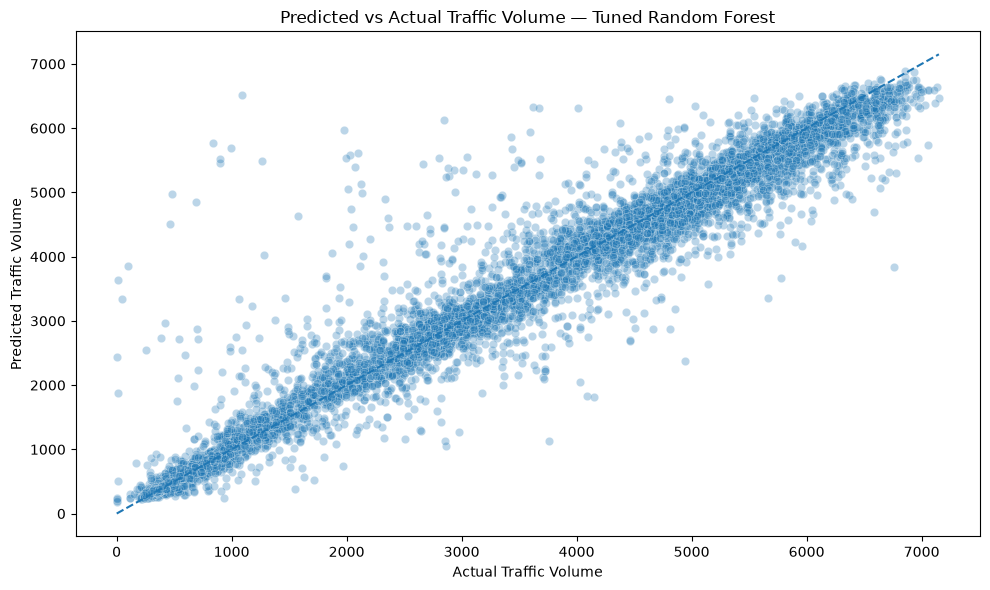

In [117]:
# C4 — Predicted vs Actual Values
# Using the tuned Random Forest model

# Get predictions from the tuned Random Forest
best_predictions = tuned_rf_predictions

# Create the scatter plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_test,
    y=best_predictions,
    alpha=0.3
)

# Add a perfect-prediction reference line
min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Predicted vs Actual Traffic Volume — Tuned Random Forest")
plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")

plt.tight_layout()
plt.show()

### Observation — Predicted vs Actual Plot

The predicted-versus-actual plot shows that most observations are concentrated around the diagonal reference line, indicating that the tuned Random Forest predicts traffic volume reasonably accurately. The strong alignment between predicted and actual values is consistent with the high test-set R² of 
**0.9561** achieved by the tuned Random Forest.

Some observations are located farther from the reference line, indicating larger prediction errors for certain traffic-volume values. Overall, the model demonstrates a strong agreement between predicted and actual traffic volume.

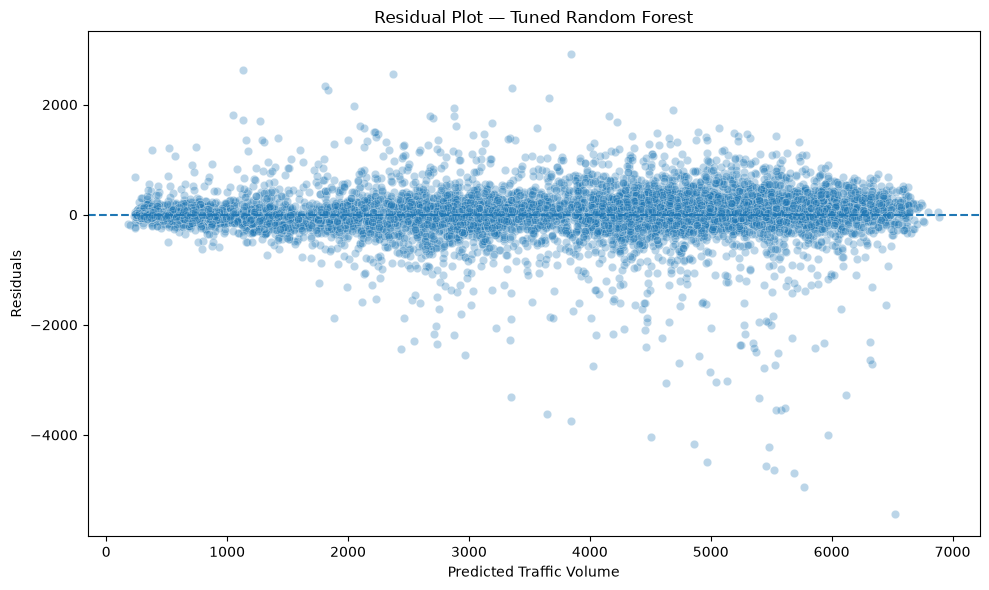

In [121]:
# C4 — Residual Plot
# Residual = Actual value - Predicted value

# Calculate residuals
residuals = y_test - best_predictions

# Create the residual plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=best_predictions,
    y=residuals,
    alpha=0.3
)

# Add a horizontal zero-error reference line
plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot — Tuned Random Forest")
plt.xlabel("Predicted Traffic Volume")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

### Observation — Residual Plot

The residuals are generally centered around the zero reference line, indicating that the model does not show a strong overall systematic bias in its predictions.

However, the spread of the residuals becomes wider at higher predicted traffic-volume values. There are also several observations with large positive and negative residuals. This indicates that the prediction error is not completely constant across all traffic-volume levels and suggests the presence of some heteroscedasticity.

Despite these errors, most observations remain relatively close to the zero-residual line, which is consistent with the strong overall performance of the tuned Random Forest model.

In [119]:
# C4 — Feature Importance of the Tuned Random Forest

# Get feature importance values from the tuned Random Forest
feature_importance = tuned_rf_model.feature_importances_

# Create a DataFrame containing feature names and importance
importance_df = pd.DataFrame({
    "Feature": processed_feature_names,
    "Importance": feature_importance
})

# Sort features from most important to least important
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Display the top 20 most important features
print("Top 20 Most Important Features:")
display(importance_df.head(20))

Top 20 Most Important Features:


,Feature,Importance
0,cat__traffic_period_Night,0.583807
1,num__hour,0.254035
2,num__day_of_week,0.063320
3,num__is_weekend,0.037589
4,num__temp,0.023758
5,num__month,0.009151
6,num__year,0.006722
7,cat__traffic_period_Afternoon,0.005586
8,num__clouds_all,0.003327
9,num__rain_1h,0.002370


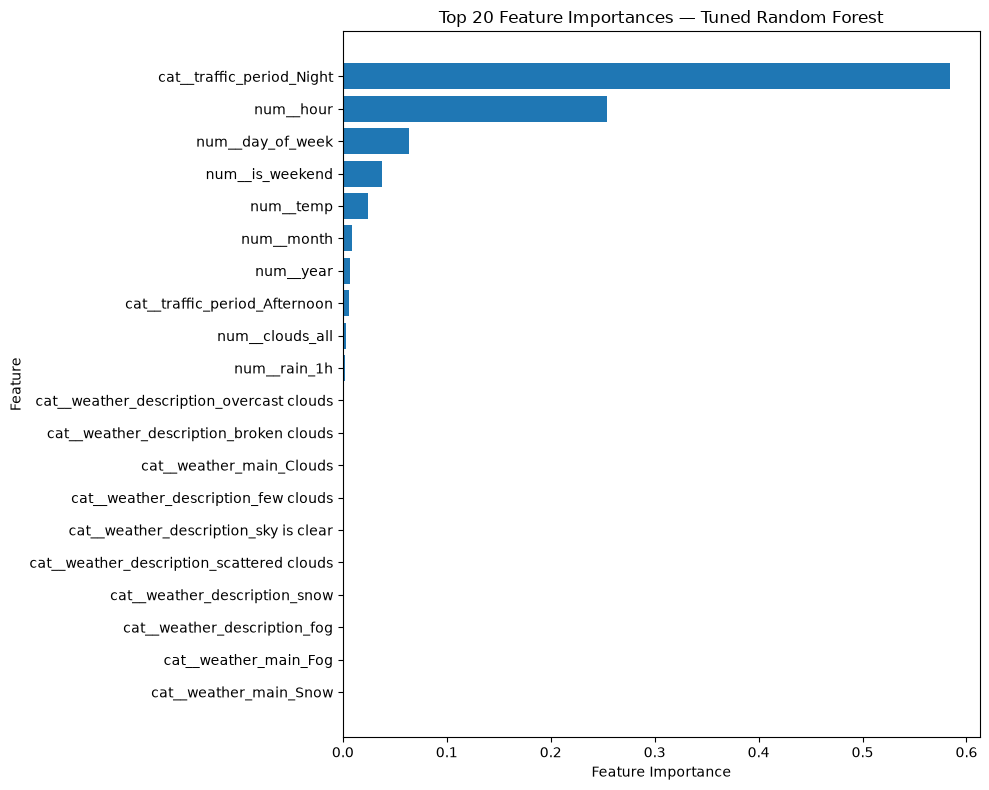

In [120]:
# C4 — Plot the Top 20 Most Important Features

# Select the top 20 features
top_features = importance_df.head(20).sort_values(
    by="Importance",
    ascending=True
)

# Create the horizontal bar plot
plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 20 Feature Importances — Tuned Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Observation — Feature Importance

The feature-importance analysis shows that time-related features are the most influential predictors of traffic volume.

The `traffic_period_Night` feature has the highest importance (**0.5838**), followed by `hour` (**0.2540**) and `day_of_week` (**0.0633**). The weekend indicator also contributes to the model with an importance of **0.0376**.

Temperature has a smaller but noticeable importance of **0.0238**, while rainfall and cloud coverage contribute relatively little to the model. Most of the individual weather-category features have very small importance values.

These results indicate that traffic volume is strongly associated with temporal patterns, particularly the time of day and day of the week. The results also demonstrate why the engineered time-based features were useful for the regression models.